In [4]:
"""
Sky map (azimuth/elevation as seen from Rubin) of the ODC constellation at
twilight, for 3 dates. Notebook version: pasting this cell only DEFINES
functions -- nothing runs until you call run() in another cell.

    run(dates=[...], subsample_n=10, layout="horizontal", dot_scale=2.5)  # 1/10th
    run(dates=[...], subsample_n=1)                                       # full

    legend_fontsize=...   text size of the counts legend (default 30 vertical,
                          36 horizontal; title and markers scale with it)
"""

import gc
import glob
import os
import pickle
import re
import warnings

import numpy as np
# NOTE: no matplotlib.use("Agg") -- that forces a save-only backend which
# would never display inline in a notebook. Leaving the backend unset lets
# Jupyter's inline backend take over (and plain scripts still save fine).
import matplotlib.pyplot as plt
import astropy.time
import astropy.units as u
from astropy.coordinates import EarthLocation, AltAz, SkyCoord, get_sun
from sgp4.api import Satrec
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────────────────────────────────────

STEP1_DIR     = "streak_output_sgp4"        # tles_shellNNN_YYYY-MM-DD.pkl
OUTPUT_DIR    = "sky_scatter_color_plots"
SUN_EL_TARGET = -21.0
MIN_EL_SAT    = 0.0
N_SUMMARY     = 4      # evenly spaced dates; first 3 used (unless dates= given)

RUBIN_LAT  = -30.244639
RUBIN_LON  = -70.749417
RUBIN_ELEV =  2663.0

# Rubin TMA operational elevation limits
RUBIN_MIN_EL = 15.0
RUBIN_MAX_EL = 86.5

RUBIN_LOC = EarthLocation(
    lat    = RUBIN_LAT  * u.deg,
    lon    = RUBIN_LON  * u.deg,
    height = RUBIN_ELEV * u.m,
)

# ── Colours ──────────────────────────────────────────────────────────────────
BG_COLOR       = "white"
FIG_BG_COLOR   = "white"
TEXT_COLOR     = "black"
GRID_COLOR     = "#888888"
CARDINAL_COLOR = "#222222"
SHADOW_COLOR   = "#999999"
LEGEND_FACE    = "#F5F5F5"
LEGEND_EDGE    = "#CCCCCC"
SUN_COLOR      = "#E69F00"
RUBIN_EL_COLOR = "#D55E00"

# Drawn in this order (later layers paint on top of earlier ones)
LAYER_COLORS = {
    "SSO-99":   "#009E73",   # green
    "H-LEO-30": "#FF44CC",   # pink
    "SSO-97":   "#0072B2",   # blue
    "LEO-30":   "#FFA500",   # orange
}

LAYER_SHORT = {k: k for k in LAYER_COLORS}

# Marker sizes / opacity. dot_scale in run() multiplies both sizes -- raise it
# (e.g. 2-3) for the 1/10th constellation, whose trails are 10x sparser.
SHADOW_S = 1.5
SUNLIT_S = 2.0
ALPHA    = 1.0

# Legend ("summary table") sizes per layout: (text, title, marker) in points.
# Override the text size with legend_fontsize= in run(); the title and marker
# sizes scale along with it.
LEGEND_SIZES = {"vertical": (30, 20, 20), "horizontal": (36, 26, 26)}


def shell_id_to_layer(shell_id):
    if  1 <= shell_id <= 25:  return "LEO-30"
    if 26 <= shell_id <= 50:  return "H-LEO-30"
    if 51 <= shell_id <= 72:  return "SSO-97"
    if 73 <= shell_id <= 94:  return "SSO-99"
    return "LEO-30"


def pkl_to_shell_id(pkl_path):
    base = os.path.basename(pkl_path)
    return int(base.split("_")[1].replace("shell", ""))


# ─────────────────────────────────────────────────────────────────────────────
# 1/N subsampling (same fixed-stride rule as 1tenth_pixelloss.py)
# ─────────────────────────────────────────────────────────────────────────────

_NAME_RE = re.compile(r"SH\d+-(\d+)-\d+")


def subsample_tles(tle_lines, every_n):
    """
    Within ONE shell's TLE list, keep every Nth satellite per plane
    (stride positions 0, N, 2N, ... of the satellites sorted by name, i.e.
    sat1, sat11, sat21, ... for N=10). Names are SHxx-PPP-SSS (Step1.py), so
    the plane is read straight from the name. every_n <= 1 returns the list
    unchanged.
    """
    if every_n is None or every_n <= 1:
        return tle_lines

    by_plane = {}
    for tle in tle_lines:
        parts = tle.strip().split("\n")
        if len(parts) != 3:
            continue
        m = _NAME_RE.search(parts[0])
        plane = m.group(1) if m else "?"      # unnamed -> one big "plane"
        by_plane.setdefault(plane, []).append((parts[0].strip(), tle))

    kept = []
    for plane, sats in by_plane.items():
        sats.sort(key=lambda t: t[0])
        kept.extend(tle for _, tle in sats[0::every_n])
    return kept


# ─────────────────────────────────────────────────────────────────────────────
# Sun helpers
# ─────────────────────────────────────────────────────────────────────────────

def get_sun_elevation(mjd_utc, location):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        t     = astropy.time.Time(mjd_utc, format="mjd", scale="utc")
        frame = AltAz(obstime=t, location=location)
        sun   = get_sun(t).transform_to(frame)
    return float(sun.alt.deg)


def find_sun_el_time(date_str, target_el, location, search_window_h=(18, 32)):
    date_t  = astropy.time.Time(date_str + "T00:00:00", format="isot", scale="utc")
    mjd0    = date_t.mjd
    t_start = mjd0 + search_window_h[0] / 24.0
    t_end   = mjd0 + search_window_h[1] / 24.0

    el_start = get_sun_elevation(t_start, location)
    el_end   = get_sun_elevation(t_end,   location)

    if not (el_start > target_el > el_end):
        for h in np.linspace(search_window_h[0], search_window_h[1], 200):
            t1 = mjd0 + h / 24.0
            t2 = mjd0 + (h + 0.25) / 24.0
            e1 = get_sun_elevation(t1, location)
            e2 = get_sun_elevation(t2, location)
            if e1 >= target_el >= e2:
                t_start, t_end = t1, t2
                break
        else:
            return None

    for _ in range(60):
        t_mid  = (t_start + t_end) / 2.0
        el_mid = get_sun_elevation(t_mid, location)
        if abs(el_mid - target_el) < 0.005:
            return t_mid
        if el_mid > target_el:
            t_start = t_mid
        else:
            t_end = t_mid

    return (t_start + t_end) / 2.0


# ─────────────────────────────────────────────────────────────────────────────
# SGP4 helpers
# ─────────────────────────────────────────────────────────────────────────────

def _gmst_rad(jd):
    T = (jd - 2451545.0) / 36525.0
    g = (67310.54841 + (876600 * 3600 + 8640184.812866) * T
         + 0.093104 * T**2 - 6.2e-6 * T**3)
    return np.radians(g % 86400 / 240.0)


def teme_to_gcrs(pos, jd):
    th = _gmst_rad(jd)
    ct, st = np.cos(th), np.sin(th)
    return np.array([ ct * pos[0] + st * pos[1],
                     -st * pos[0] + ct * pos[1],
                      pos[2]])


def is_sunlit(pos_gcrs, jd):
    RE  = 6378.137
    n   = jd - 2451545.0
    L   = np.radians((280.460 + 0.9856474 * n) % 360)
    g   = np.radians((357.528 + 0.9856003 * n) % 360)
    lam = L + np.radians(1.915 * np.sin(g) + 0.020 * np.sin(2 * g))
    eps = np.radians(23.439 - 4e-7 * n)
    sun = np.array([np.cos(lam),
                    np.cos(eps) * np.sin(lam),
                    np.sin(eps) * np.sin(lam)])
    proj = -np.dot(sun, pos_gcrs)
    r2   = np.dot(pos_gcrs, pos_gcrs)
    return bool((proj < 0) or (r2 - proj**2 > RE**2))


def radec_to_azel_batch(ra, dec, mjd, location):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        t      = astropy.time.Time(mjd, format="mjd", scale="utc")
        frame  = AltAz(obstime=t, location=location)
        coords = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")
        aa     = coords.transform_to(frame)
    return aa.az.deg, aa.alt.deg


# ─────────────────────────────────────────────────────────────────────────────
# Propagate all shells at one moment
# ─────────────────────────────────────────────────────────────────────────────

def propagate_all_shells(date_str, mjd_obs, step1_dir, subsample_n=1):
    jd_full = mjd_obs + 2400000.5
    jd1     = float(np.floor(jd_full))
    jd2     = float(jd_full - jd1)

    pkl_files = sorted(glob.glob(
        os.path.join(step1_dir, f"tles_shell*_{date_str}.pkl")
    ))
    if not pkl_files:
        print(f"  [WARN] No TLE pkls for {date_str}")
        return None

    print(f"  {date_str} | {len(pkl_files)} shells"
          + (f" | keeping 1 of every {subsample_n} satellites per plane"
             if subsample_n > 1 else ""))

    all_az, all_el, all_sun, all_layer = [], [], [], []
    n_total = n_fail = 0

    for pkl_path in pkl_files:
        shell_id = pkl_to_shell_id(pkl_path)
        layer    = shell_id_to_layer(shell_id)

        with open(pkl_path, "rb") as f:
            data = pickle.load(f)
        tle_lines = data["tle_lines"] if isinstance(data, dict) else data
        tle_lines = subsample_tles(tle_lines, subsample_n)

        ra_l, dec_l, sun_l = [], [], []

        for tle in tle_lines:
            parts = tle.strip().split("\n")
            if len(parts) != 3:
                n_fail += 1
                continue
            _, l1, l2 = parts
            try:
                sat = Satrec.twoline2rv(l1, l2)
            except Exception:
                n_fail += 1
                continue

            e, r, _ = sat.sgp4(jd1, jd2)
            if e != 0:
                n_fail += 1
                continue

            pos_teme = np.array(r)
            pos_gcrs = teme_to_gcrs(pos_teme, jd_full)
            norm     = np.linalg.norm(pos_gcrs)
            ra       = np.degrees(np.arctan2(pos_gcrs[1], pos_gcrs[0])) % 360
            dec      = np.degrees(np.arcsin(np.clip(pos_gcrs[2] / norm, -1, 1)))
            sunlit   = is_sunlit(pos_gcrs, jd_full)

            ra_l.append(ra); dec_l.append(dec); sun_l.append(sunlit)
            n_total += 1

        if not ra_l:
            continue

        ra_arr  = np.array(ra_l,  dtype=np.float32)
        dec_arr = np.array(dec_l, dtype=np.float32)
        sun_arr = np.array(sun_l, dtype=bool)

        az_arr, el_arr = radec_to_azel_batch(ra_arr, dec_arr, mjd_obs, RUBIN_LOC)

        above   = el_arr >= MIN_EL_SAT
        n_above = above.sum()
        all_az.append(az_arr[above])
        all_el.append(el_arr[above])
        all_sun.append(sun_arr[above])
        all_layer.extend([layer] * int(n_above))

        del ra_l, dec_l, sun_l, tle_lines
        gc.collect()

    if not all_az:
        return None

    az_all    = np.concatenate(all_az)
    el_all    = np.concatenate(all_el)
    sun_all   = np.concatenate(all_sun)
    layer_all = np.array(all_layer)

    print(f"  {date_str} | total={n_total:,}  above_horizon={len(az_all):,}  "
          f"sunlit={sun_all.sum():,}  failed={n_fail:,}")

    return {"az": az_all, "el": el_all, "sunlit": sun_all,
            "layer": layer_all, "n_total": n_total}


# ─────────────────────────────────────────────────────────────────────────────
# Plot one panel -- returns stats dict for the caption
# ─────────────────────────────────────────────────────────────────────────────

def plot_sky_panel(az_deg, el_deg, sunlit, layer, date_str, mjd_obs, ax,
                   panel_label="", layout="vertical", dot_scale=1.0,
                   legend_fontsize=None):
    ax.set_facecolor(BG_COLOR)

    base_fs, base_title, base_ms = LEGEND_SIZES[layout]
    leg_fs       = legend_fontsize if legend_fontsize else base_fs
    k            = leg_fs / base_fs
    leg_title_fs = base_title * k
    leg_ms       = base_ms * k

    R = 1.0 - el_deg / 90.0
    X = -R * np.sin(np.radians(az_deg))
    Y =  R * np.cos(np.radians(az_deg))

    th = np.linspace(0, 2 * np.pi, 361)

    # Within-Rubin-window counts (what the legend reports)
    mask_rubin     = (el_deg >= RUBIN_MIN_EL) & (el_deg <= RUBIN_MAX_EL)
    n_rubin_total  = int(mask_rubin.sum())
    n_rubin_sunlit = int((sunlit & mask_rubin).sum())
    n_rubin_shadow = int((~sunlit & mask_rubin).sum())

    # Shadow (plot everything above the horizon, count only the Rubin window)
    mask_ns = ~sunlit
    if mask_ns.sum() > 0:
        ax.scatter(X[mask_ns], Y[mask_ns], s=SHADOW_S * dot_scale,
                   c=SHADOW_COLOR, alpha=ALPHA, linewidths=0,
                   zorder=1, rasterized=True)

    legend_elements   = []
    n_sunlit_by_layer = {}
    n_rubin_by_layer  = {}

    for lyr, color in LAYER_COLORS.items():
        mask_s = sunlit & (layer == lyr)
        n_sunlit_by_layer[lyr] = int(mask_s.sum())

        n_r = int((sunlit & mask_rubin & (layer == lyr)).sum())
        n_rubin_by_layer[lyr] = n_r

        if mask_s.sum() == 0:
            continue
        ax.scatter(X[mask_s], Y[mask_s], s=SUNLIT_S * dot_scale, c=color,
                   alpha=ALPHA, linewidths=0, zorder=2, rasterized=True)

        legend_elements.append(
            Line2D([0], [0], marker="o", color="none", markerfacecolor=color,
                   markersize=leg_ms, label=f"{LAYER_SHORT[lyr]}  ({n_r:,})",
                   linewidth=0))

    legend_elements.append(
        Line2D([0], [0], marker="o", color="none", markerfacecolor=SHADOW_COLOR,
               markersize=leg_ms, label=f"Shadow  ({n_rubin_shadow:,})", linewidth=0))
    legend_elements.append(
        Line2D([0], [0], color=RUBIN_EL_COLOR, lw=2.0, linestyle="-",
               label=f"Rubin limits ({RUBIN_MIN_EL:.1f}°–{RUBIN_MAX_EL:.1f}°)"
                     f"  total: {n_rubin_total:,}"))

    # Horizon circle
    ax.plot(np.cos(th), np.sin(th), color="black", lw=1.5, zorder=5)

    # 60 deg reference circle
    r_60 = 1.0 - 60.0 / 90.0
    ax.plot(r_60 * np.cos(th), r_60 * np.sin(th), color=GRID_COLOR, lw=0.8,
            linestyle="--", zorder=4)
    ax.text(0, r_60 + 0.03, "60°", ha="center", va="bottom", fontsize=14,
            color=GRID_COLOR, zorder=6)

    # Rubin minimum / maximum elevation circles
    r_min = 1.0 - RUBIN_MIN_EL / 90.0
    ax.plot(r_min * np.cos(th), r_min * np.sin(th), color=RUBIN_EL_COLOR,
            lw=2.0, linestyle="-", zorder=5)
    ax.text(0, r_min + 0.03, f"{RUBIN_MIN_EL:.1f}° (min)", ha="center",
            va="bottom", fontsize=13, color=RUBIN_EL_COLOR,
            fontweight="bold", zorder=6)

    r_max = 1.0 - RUBIN_MAX_EL / 90.0
    ax.plot(r_max * np.cos(th), r_max * np.sin(th), color=RUBIN_EL_COLOR,
            lw=2.0, linestyle="-", zorder=5)
    ax.text(0, r_max - 0.06, f"{RUBIN_MAX_EL:.1f}° (max)", ha="center",
            va="top", fontsize=13, color=RUBIN_EL_COLOR,
            fontweight="bold", zorder=6)

    # Cardinal labels
    off = 1.12
    for lbl, x, y in [("N", 0, off), ("S", 0, -off),
                      ("E", -off, 0), ("W", off, 0)]:
        ax.text(x, y, lbl, ha="center", va="center", color=CARDINAL_COLOR,
                fontsize=22, fontweight="bold", zorder=6)

    # Legend (counts are Rubin-window only)
    if layout == "horizontal":
        leg = ax.legend(handles=legend_elements, loc="upper center",
                        bbox_to_anchor=(0.5, -0.02), fontsize=leg_fs,
                        facecolor=LEGEND_FACE, edgecolor=LEGEND_EDGE,
                        labelcolor=TEXT_COLOR, framealpha=0.90, ncol=1)
    else:
        leg = ax.legend(handles=legend_elements, loc="lower center",
                        bbox_to_anchor=(0.1, -0.05), fontsize=leg_fs,
                        facecolor=LEGEND_FACE, edgecolor=LEGEND_EDGE,
                        labelcolor=TEXT_COLOR, framealpha=0.90, ncol=1)
    leg.set_title(f"Counts within {RUBIN_MIN_EL:.1f}°–{RUBIN_MAX_EL:.1f}° window",
                  prop={"size": leg_title_fs, "style": "italic"})

    # Sun position marker
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        t_obs    = astropy.time.Time(mjd_obs, format="mjd", scale="utc")
        frame    = AltAz(obstime=t_obs, location=RUBIN_LOC)
        sun_c    = get_sun(t_obs).transform_to(frame)
        sun_az   = float(sun_c.az.deg)
        sun_el_a = float(sun_c.alt.deg)

    r_s = 1.06
    ax.text(-r_s * np.sin(np.radians(sun_az)), r_s * np.cos(np.radians(sun_az)),
            "☉", ha="center", va="center", fontsize=28, color=SUN_COLOR, zorder=7)

    utc_str = astropy.time.Time(mjd_obs, format="mjd", scale="utc").iso[:16]
    ax.set_title(f"({panel_label})  {date_str}\n"
                 f"{utc_str} UTC  |  Sun el ~ {sun_el_a:.1f}°",
                 color=TEXT_COLOR, fontsize=18, fontweight="bold", pad=10)

    ax.set_xlim(-1.25, 1.25)
    ax.set_ylim(-1.25, 1.25)
    ax.set_aspect("equal")
    ax.axis("off")

    return {
        "date": date_str, "utc": utc_str, "sun_el": sun_el_a,
        "n_above": int(len(az_deg)), "n_sunlit": int(sunlit.sum()),
        "n_shadow": int(mask_ns.sum()),
        "n_rubin_total": n_rubin_total, "n_rubin_sunlit": n_rubin_sunlit,
        "n_rubin_shadow": n_rubin_shadow,
        "by_layer": n_sunlit_by_layer, "rubin_by_layer": n_rubin_by_layer,
    }


# ─────────────────────────────────────────────────────────────────────────────
# Caption
# ─────────────────────────────────────────────────────────────────────────────

def build_caption(panel_stats, subsample_n=1):
    scale_note = (f" Only 1 of every {subsample_n} satellites per orbital plane "
                  f"is simulated (a 1/{subsample_n}-scale constellation)."
                  if subsample_n > 1 else "")
    lines = [
        "Figure X. Stereographic sky maps of ODC constellation satellites "
        f"as seen from Rubin Observatory (lat {RUBIN_LAT} deg, "
        f"lon {RUBIN_LON} deg, {RUBIN_ELEV} m) at astronomical twilight "
        f"(Sun elevation ~ {SUN_EL_TARGET} deg).{scale_note} "
        "Colored points are sunlit satellites; shell abbreviations "
        "(LEO-30, H-LEO-30, SSO-97, SSO-99) refer to Table 1. "
        "Gray points are satellites in Earth's shadow. "
        f"Solid vermillion circles mark the Rubin TMA operational elevation "
        f"limits ({RUBIN_MIN_EL:.1f} deg min, {RUBIN_MAX_EL:.1f} deg max); "
        "satellites outside these circles cannot be observed. "
        "Legend counts give the number of satellites within the Rubin "
        "observable window only. "
        "The Sun symbol indicates the Sun's azimuth direction. "
        "Statistics per panel (within Rubin window):"
    ]
    for i, s in enumerate(panel_stats):
        by_layer = ", ".join(f"{k}: {v:,}" for k, v in s["rubin_by_layer"].items()
                             if v > 0)
        lines.append(
            f"  ({chr(97 + i)}) {s['date']} {s['utc']} UTC -- "
            f"{s['n_rubin_total']:,} within Rubin limits "
            f"({s['n_rubin_sunlit']:,} sunlit [{by_layer}], "
            f"{s['n_rubin_shadow']:,} in shadow); "
            f"{s['n_above']:,} above horizon in total."
        )
    return "\n".join(lines)


# ─────────────────────────────────────────────────────────────────────────────
# Main entry point (callable directly from a notebook)
# ─────────────────────────────────────────────────────────────────────────────

def run(step1_dir=STEP1_DIR, output_dir=OUTPUT_DIR, dates=None,
        subsample_n=1, layout="vertical", dot_scale=1.0, show=True,
        legend_fontsize=None):
    """
    dates       : list of up to 3 'YYYY-MM-DD' strings. None -> pick N_SUMMARY
                  evenly spaced dates from whatever is in step1_dir (first 3
                  used), exactly like the original script.
    subsample_n : 1 = full constellation, 10 = 1/10th (every 10th sat/plane).
    layout      : 'vertical' (3 rows, the original) or 'horizontal' (1 row).
    dot_scale   : multiplies marker sizes (try 2-3 for the sparser 1/10th run).
    legend_fontsize : text size of the counts legend. None -> 30 (vertical)
                  or 36 (horizontal); title and markers scale with it.
    """
    os.makedirs(output_dir, exist_ok=True)

    if dates is None:
        all_pkls = sorted(glob.glob(os.path.join(step1_dir, "tles_shell001_*.pkl")))
        all_dates = sorted({
            os.path.basename(p).replace("tles_shell001_", "").replace(".pkl", "")
            for p in all_pkls
        })
        if not all_dates:
            raise FileNotFoundError(
                f"No tles_shell001_*.pkl found in {step1_dir!r}")
        print(f"Found {len(all_dates)} dates: {all_dates[0]} -> {all_dates[-1]}")
        idx = np.linspace(0, len(all_dates) - 1, N_SUMMARY, dtype=int)
        summary_dates = [all_dates[i] for i in idx]
    else:
        summary_dates = list(dates)
    # de-duplicate while preserving order (with few dates, linspace can
    # pick the same date twice, which would draw the same panel twice)
    summary_dates = list(dict.fromkeys(summary_dates))
    print(f"Summary dates: {summary_dates}")

    summary_data = {}
    for date_str in summary_dates:
        print(f"\n[Processing] {date_str}")
        mjd_obs = find_sun_el_time(date_str, SUN_EL_TARGET, RUBIN_LOC)
        if mjd_obs is None:
            print(f"  [WARN] sun_el={SUN_EL_TARGET} deg not found -- skipping")
            continue
        actual_el = get_sun_elevation(mjd_obs, RUBIN_LOC)
        result = propagate_all_shells(date_str, mjd_obs, step1_dir, subsample_n)
        if result:
            summary_data[date_str] = {"result": result, "mjd_obs": mjd_obs,
                                      "sun_el": actual_el}

    valid = [d for d in summary_dates if d in summary_data][:3]
    if not valid:
        raise RuntimeError("No dates produced data -- nothing to plot.")

    plt.rcParams.update({
        "font.size": 22, "legend.fontsize": 15, "axes.titlesize": 18,
        "figure.facecolor": FIG_BG_COLOR,
    })

    if layout == "horizontal":
        fig, axes = plt.subplots(1, 3, figsize=(45, 17))
    else:
        fig, axes = plt.subplots(3, 1, figsize=(16, 45))
    axes = np.atleast_1d(axes)
    fig.patch.set_facecolor(FIG_BG_COLOR)

    all_stats = []
    for i, date_str in enumerate(valid):
        sd = summary_data[date_str]
        all_stats.append(plot_sky_panel(
            az_deg=sd["result"]["az"], el_deg=sd["result"]["el"],
            sunlit=sd["result"]["sunlit"], layer=sd["result"]["layer"],
            date_str=date_str, mjd_obs=sd["mjd_obs"], ax=axes[i],
            panel_label="abc"[i], layout=layout, dot_scale=dot_scale,
            legend_fontsize=legend_fontsize))
    for j in range(len(valid), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 1], h_pad=1.0)

    if subsample_n == 1:
        suffix = ""
    elif subsample_n == 10:
        suffix = "_tenth_constellation"
    else:
        suffix = f"_1of{subsample_n}"
    if layout == "horizontal":
        suffix += "_horizontal"

    png = os.path.join(output_dir, f"sky_scatter_color_summary_3panel{suffix}.png")
    plt.savefig(png, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"\n[SAVED] {png}")
    if show:
        plt.show()
    plt.close(fig)

    caption = build_caption(all_stats, subsample_n)
    print("\n" + "=" * 70)
    print("FIGURE CAPTION (copy into paper):")
    print("=" * 70)
    print(caption)
    cap_path = os.path.join(output_dir, f"sky_summary_caption{suffix}.txt")
    with open(cap_path, "w") as f:
        f.write(caption)
    print(f"\n[SAVED] caption -> {cap_path}")
    return png, all_stats

In [ ]:
DATES = ["2026-11-01", "2027-02-27", "2027-07-04"]
png_tenth, stats_tenth = run(dates=DATES, subsample_n=10, layout="horizontal", dot_scale=2.5)

Summary dates: ['2026-11-01', '2027-02-27', '2027-07-04']

[Processing] 2026-11-01
  2026-11-01 | 94 shells | keeping 1 of every 10 satellites per plane
  2026-11-01 | total=100,896  above_horizon=50,401  sunlit=37,245  failed=0

[Processing] 2027-02-27
  2027-02-27 | 94 shells | keeping 1 of every 10 satellites per plane


Summary dates: ['2026-11-01', '2027-02-27', '2027-07-04']

[Processing] 2026-11-01
  2026-11-01 | 94 shells
  2026-11-01 | total=998,240  above_horizon=498,329  sunlit=369,890  failed=0

[Processing] 2027-02-27
  2027-02-27 | 94 shells
  2027-02-27 | total=998,240  above_horizon=499,124  sunlit=307,713  failed=0

[Processing] 2027-07-04
  2027-07-04 | 94 shells
  2027-07-04 | total=998,240  above_horizon=499,094  sunlit=242,617  failed=0

[SAVED] sky_scatter_color_plots/sky_scatter_color_summary_3panel.png


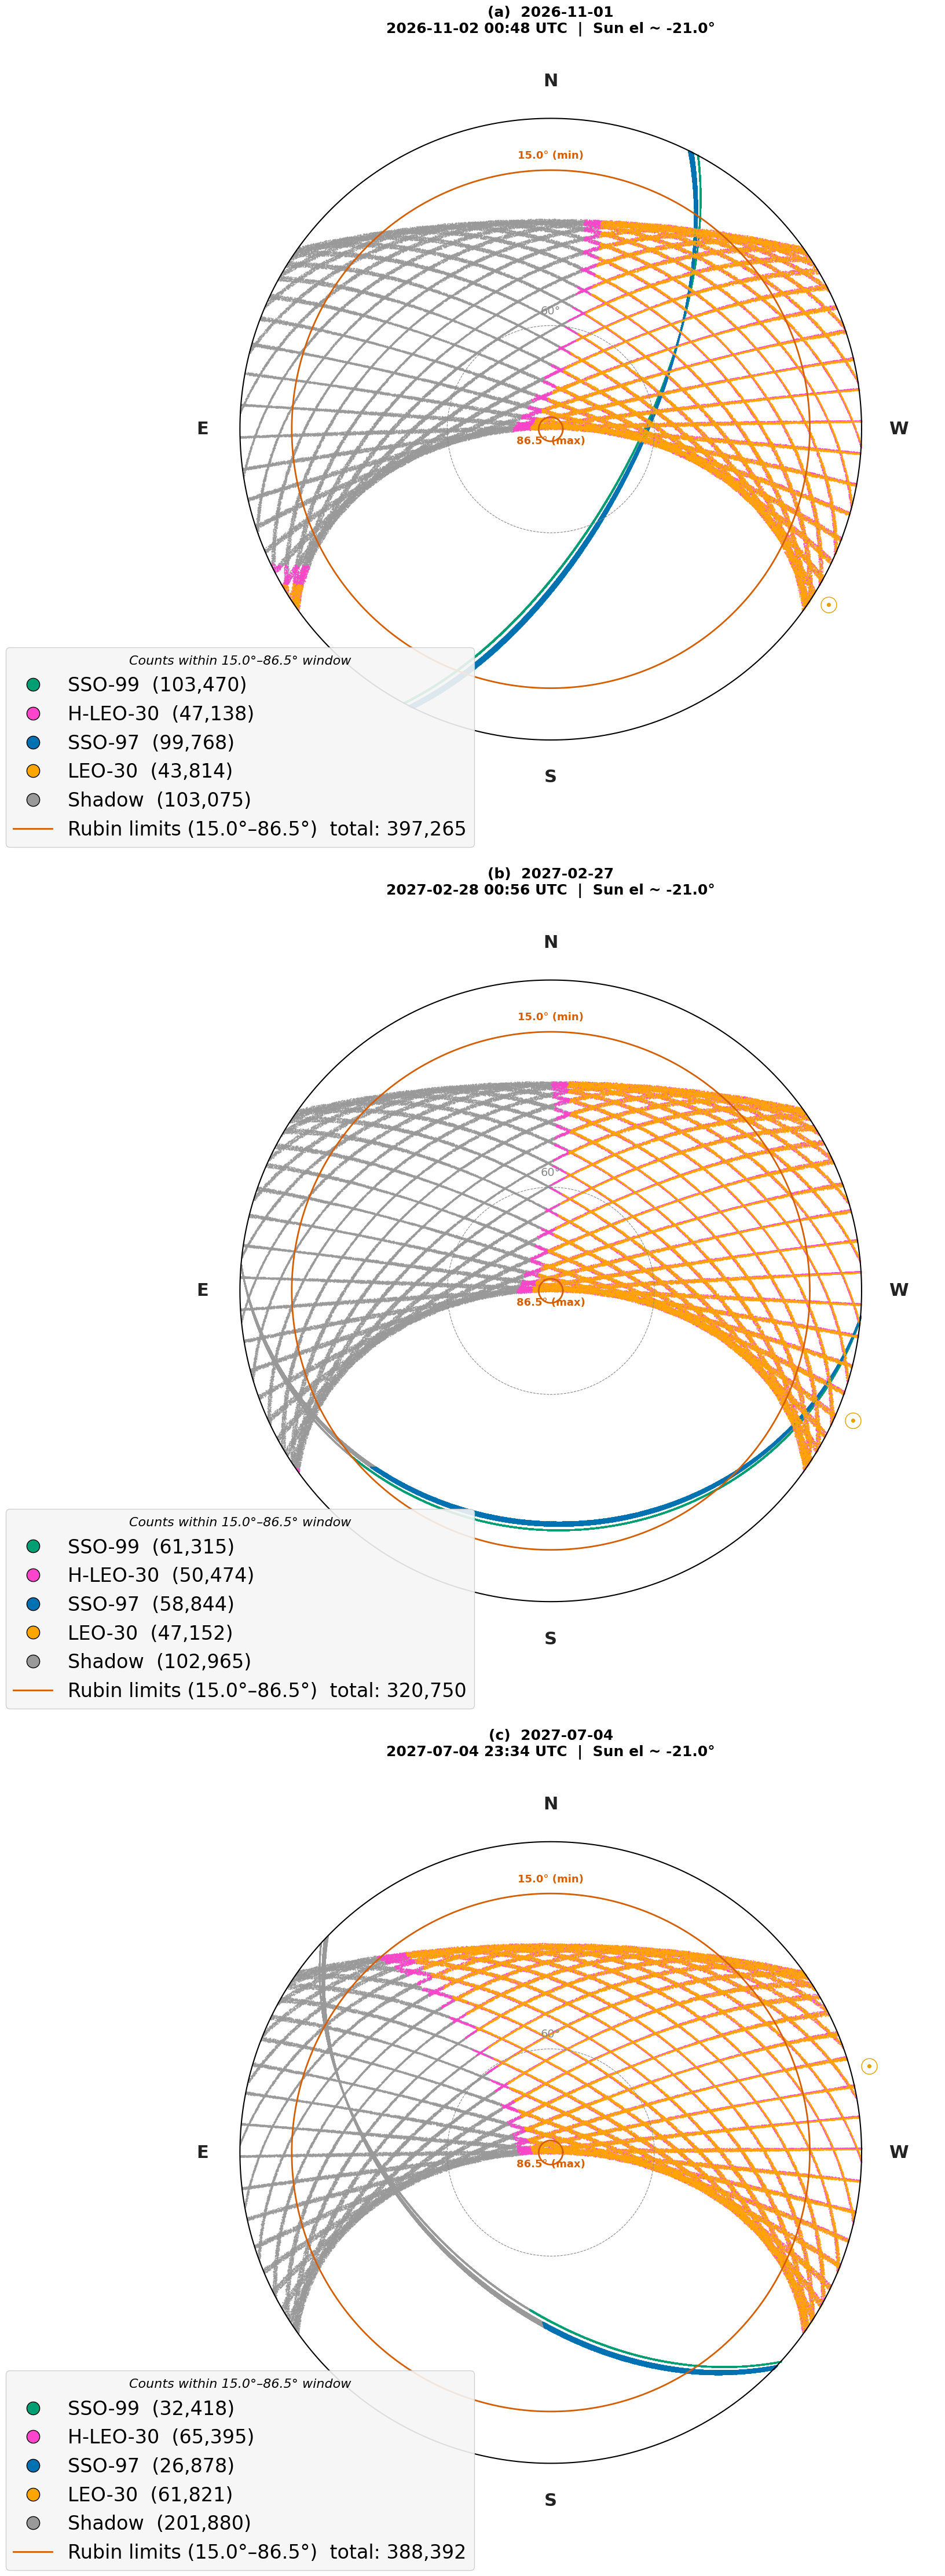


FIGURE CAPTION (copy into paper):
Figure X. Stereographic sky maps of ODC constellation satellites as seen from Rubin Observatory (lat -30.244639 deg, lon -70.749417 deg, 2663.0 m) at astronomical twilight (Sun elevation ~ -21.0 deg). Colored points are sunlit satellites; shell abbreviations (LEO-30, H-LEO-30, SSO-97, SSO-99) refer to Table 1. Gray points are satellites in Earth's shadow. Solid vermillion circles mark the Rubin TMA operational elevation limits (15.0 deg min, 86.5 deg max); satellites outside these circles cannot be observed. Legend counts give the number of satellites within the Rubin observable window only. The Sun symbol indicates the Sun's azimuth direction. Statistics per panel (within Rubin window):
  (a) 2026-11-01 2026-11-02 00:48 UTC -- 397,265 within Rubin limits (294,190 sunlit [SSO-99: 103,470, H-LEO-30: 47,138, SSO-97: 99,768, LEO-30: 43,814], 103,075 in shadow); 498,329 above horizon in total.
  (b) 2027-02-27 2027-02-28 00:56 UTC -- 320,750 within Rubin 

In [ ]:
png_full, stats_full = run(dates=DATES, subsample_n=1)